# Anomaly Detection in Mobile Networks

This notebook describes anomaly detection methods for drive test data.

**Target audience:** telecom engineers and PhD students  

## Learning objectives
1. Compute descriptive statistics for the target KPI
2. Apply and compare rule-based univariate anomaly detectors
3. Generate a controlled contaminated dataset with known inliers and outliers for method validation
4. Understand the robust covariance method for bivariate data 
5. Evaluate anomaly-detection performance with accuracy metrics 
6. Apply and compare multivariate anomaly detectors including One-Class SVM, Isolation Forest, and Local Outlier Factor.
7. Build a residual-based anomaly-detection baseline using a regression model trained on presumed normal samples.

## Notebook flow
1. Environment setup  
2. Load the clean dataset  
3. Rule-based anomaly detection
4. Robust covariance (2D)
5. One-class support vector machines (multivariate anomaly detection)
6. Other multivariate anomaly detection methods
7. Learning the normal behavior using a regression model

## 1. Environment Setup

This cell imports the scientific Python stack used throughout the notebook and configures the analysis environment.

In [416]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.covariance import EmpiricalCovariance, MinCovDet, EllipticEnvelope
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    auc,
    mean_squared_error,      # NEW
    r2_score,                # NEW
    mean_absolute_error      # NEW
)
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import RandomizedSearchCV  # NEW

from xgboost import XGBRegressor

from IPython.display import display

from srcs.misc import stat_summary
from srcs.plot_functions import plot_distribution_pair, plot_outlier_detection
from srcs.anmdet import (
    detect_outliers_iqr,
    detect_outliers_zscore,
    detect_outliers_mad,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")

## 2. Load the Clean Dataset

This cell specifies the expected dataset path, checks for the CSV file's existence, and loads it into a pandas DataFrame. Specifically, the dataset is read from the local `datasets/` directory.

In [417]:
DATA_FILE = "data_clean"
DATA_PATH = Path("datasets") / f"{DATA_FILE}.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'. "
        "Place the CSV in the expected folder or update DATA_PATH before running this notebook."
    )

data = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1",
    sep=",",
    decimal=".",
    low_memory=False,
)

print(f"Cleaned dataset shape: {data.shape[0]:,} rows x {data.shape[1]:,} columns")
display(data.head())

Cleaned dataset shape: 1,001 rows x 120 columns


,resets.sent.a2b,ack.pkts.sent.a2b,pure.acks.sent.b2a,sack.pkts.sent.b2a,dsack.pkts.sent.a2b,rexmt.data.bytes.a2b,rexmt.data.bytes.b2a,outoforder.pkts.b2a,max.segm.size.b2a,min.segm.size.a2b,min.segm.size.b2a,avg.segm.size.a2b,max.win.adv.a2b,max.win.adv.b2a,min.win.adv.a2b,avg.win.adv.a2b,min.non.zero.owin.b2a,avg.owin.a2b,avg.owin.b2a,wavg.owin.a2b,initial.window.bytes.b2a,initial.window.pkts.b2a,truncated.data.a2b,data.xmit.time.a2b,data.xmit.time.b2a,idletime.max.b2a,throughput.a2b,rtt.min.a2b,rtt.max.a2b,rtt.avg.a2b,rtt.stdev.a2b,rtt.from.3whs.a2b,rtt.full.sz.smpls.a2b,rtt.full.sz.min.a2b,rtt.full.sz.max.a2b,segs.cum.acked.a2b,triple.dupacks.a2b,max.retrans.a2b,min.retr.time.a2b,avg.retr.time.a2b,sdv.retr.time.a2b,fin.pkts.sent.a2b,rtt.min.b2a,rtt.max.b2a,rtt.avg.b2a,rtt.stdev.b2a,rtt.from.3whs.b2a,rtt.full.sz.smpls.b2a,rtt.full.sz.min.b2a,rtt.full.sz.max.b2a,rtt.full.sz.avg.b2a,post.loss.acks.b2a,rtt.min.last.b2a,rtt.max.last.b2a,rtt.avg.last.b2a,rtt.sdv.last.b2a,segs.cum.acked.b2a,triple.dupacks.b2a,max.retrans.b2a,min.retr.time.b2a,max.retr.time.b2a,avg.retr.time.b2a,sdv.retr.time.b2a,syn.pkts.sent.b2a,fin.pkts.sent.b2a,duplicate.acks.b2a,abs.downlinkdelay.min,abs.downlinkdelay.50,abs.downlinkdelay.75,abs.downlinkdelay.max,abs.uplinkdelay.25,abs.uplinkdelay.50,abs.uplinkdelay.avg,abs.uplinkdelay.75,abs.uplinkdelay.max,abs.downlinkdeltadelay.25,abs.uplinkdeltadelay.avg,abs.rtt.min,abs.rtt.25,abs.rtt.50,abs.rtt.avg,abs.rtt.75,abs.rtt.max,abs.cwin.min,abs.cwin.25,abs.cwin.50,abs.cwin.avg,abs.cwin.75,abs.cwin.max,abs.rwin.25,abs.rwin.50,abs.rwin.75,abs.rwin.max,abs.winratio.min,abs.winratio.25,abs.winratio.50,abs.winratio.avg,abs.winratio.75,abs.winratio.max,abs.radiobuffer.min,abs.radiobuffer.25,abs.radiobuffer.50,abs.radiobuffer.avg,abs.radiobuffer.75,abs.radiobuffer.max,abs.idletime.50,abs.idletime.avg,abs.idletime.75,abs.idletime.max,abs.segmentsizes.min,abs.segmentsizes.25,abs.segmentsizes.50,abs.segmentsizes.max,abs.packetlost.sum,abs.instanttp.min,abs.burst.sum,abs.rtoevents.sum,abs.theoricalmaxtp.avg,abs.theoricalmaxtp.max,transfer.datarate
0,100.0,24629.0,8.0,0.0,43.0,0.0,439348.0,17.0,65236.0,232.0,4.0,231.0,41937920.0,1946752.0,1638400.0,40000544.0,5.0,5.0,153524.0,5.0,24984.0,9.0,460.0,0.0,7.328,264.8,155.0,23.8,54.2,46.4,0.0,38.6,1.0,30.6,38.6,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,17.8,0.4,0.5,0.5,1.0,0.2,0.5,0.5,2.0,0.0,0.0,0.0,0.0,17621.0,2.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,41.0,3.0,38.0,54.0,334.0,8.0,10.0,8.460015,11.0,46.0,25.0,301.460015,0.0,38.0,48.0,55.818960,62.0,351.0,0.0,3167756.0,3475141.0,3.852855e+06,3913768.0,7352717.0,41937920.0,41937920.0,41937920.0,41937920.0,0.058522,0.076108,0.082864,0.096487,0.102346,0.292707,0.0,1606174.75,2148816.0,2.401342e+06,2784797.25,11976195.0,0.0,0.173705,0.0,252.0,1.0,2776.0,6940.0,65236.0,28.0,0.00008,14.0,3.0,3.983938e+09,3.131014e+13,448375.109
1,198.0,15636.0,42.0,0.0,22.0,0.0,72488.0,3190.0,55520.0,232.0,1.0,231.0,31455232.0,1599360.0,1638400.0,25549822.0,5.0,5.0,881001.0,3.0,19432.0,6.0,460.0,0.0,7.406,163.1,155.0,18.3,48.0,33.9,13.9,20.8,2.0,20.1,32.1,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,44.9,0.7,1.3,0.7,2.0,0.2,1.2,0.7,411.0,0.0,0.3,0.3,0.0,11922.0,62.0,1.0,0.0,170.2,34.04,0.0,5.0,0.0,2587.0,3.0,29.0,301.0,1727.0,1.0,11.0,-91.487522,14.0,200.0,12.0,1513.512478,1.0,27.0,42.0,135.827804,191.0,1741.0,0.0,1042825.0,1844469.0,3.130090e+06,3082700.0,10960755.0,21106688.0,31454208.0,31455232.0,31455232.0,0.013998,0.036512,0.059114,0.156073,0.209670,0.637286,0.0,438221.25,789585.5,1.207837e+06,1504034.50,9483651.0,0.0,0.315479,0.0,155.0,0.0,1388.0,2776.0,55520.0,397.0,0.00008,191.0,8.0,3.452638e+02,6.846370e+04,131054.310
2,5.0,25907.0,6.0,0.0,40.0,0.0,440036.0,951.0,65236.0,232.0,4.0,231.0,41943040.0,1365760.0,1638400.0,40072479.0,5.0,5.0,1084167.0,0.0,44416.0,10.0,460.0,0.0,7.351,191.0,155.0,12.7,20.5,18.4,0.0,20.5,1.0,16.3,20.5,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,44.2,0.5,1.9,0.6,1.0,0.3,0.6,0.6,521.0,0.0,0.0,0.0,0.0,22011.0,256.0,0.0,0.0,0.0,0.00,0.0,5.0,0.0,3114.0,3.0,37.0,54

## 3. Rule-based Anomaly Detection

- **IQR rule:** flag values outside the interval  
$$[Q_1 - 1.5\,IQR,\; Q_3 + 1.5\,IQR]$$
- **Z-score rule:** flag values such that  
  $$\left|\frac{x-\mu}{\sigma}\right| > 3 $$
- **MAD rule:** flag values such that  
$$ \left|0.6745\,\frac{x-\mathrm{median}}{\mathrm{MAD}}\right| > 3 $$

          transfer.datarate  log10(transfer.datarate)
count             1001.0000                 1001.0000
mean            393434.7491                    5.5131
std             198472.1685                    0.3248
min               2408.9670                    3.3818
25%             253083.9300                    5.4033
50%             381348.1200                    5.5813
75%             519678.9110                    5.7157
max            1275028.0490                    6.1055
skewness             0.4792                   -2.2380
kurtosis             0.4115                    8.1728


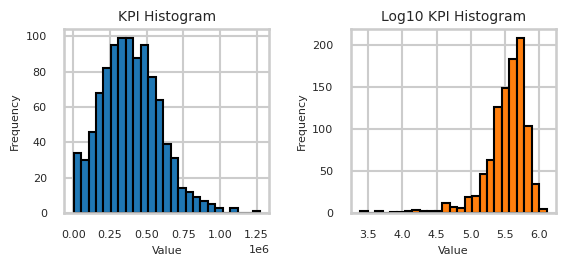

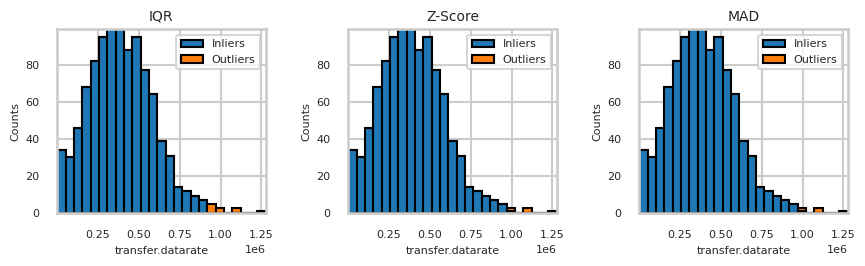

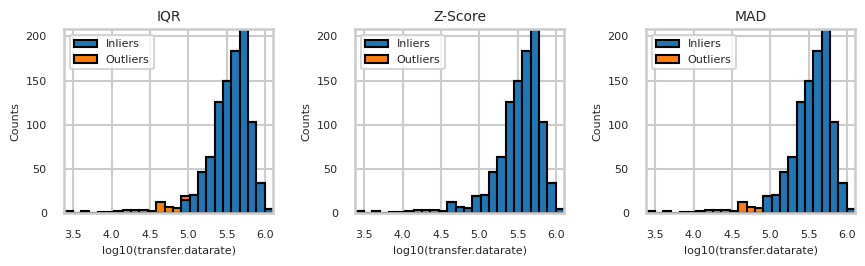

In [418]:
# -------------------------------------------------------------------
# KPI selection
# -------------------------------------------------------------------
target_kpi = 'transfer.datarate'
kpi_aux = data[target_kpi]
kpi_aux_log = np.log10(kpi_aux)

summary = pd.concat(
    [
        stat_summary(kpi_aux).rename(target_kpi),
        stat_summary(kpi_aux_log).rename(f"log10({target_kpi})"),
    ],
    axis=1,
)
print(summary.to_string(float_format=lambda x: f"{x:.4f}"))

# -------------------------------------------------------------------
# Run plots
# -------------------------------------------------------------------
plot_distribution_pair(kpi_aux, kpi_aux_log)

outliers_kpi = plot_outlier_detection(kpi_aux, xlabel=target_kpi)
outliers_kpi_log = plot_outlier_detection(
    kpi_aux_log,
    xlabel=f"log10({target_kpi})",
    suffix=" (Log10 Transformed)",
)

## 4. Robust Covariance (2D)

This cell introduces **multivariate anomaly detection** using a synthetic two-dimensional dataset with known contamination.

- `make_contaminated_data(...)` generates Gaussian inliers and injected outliers.
- `EmpiricalCovariance` estimates the classical maximum-likelihood covariance matrix.
- `MinCovDet` estimates a **robust covariance matrix** using the Minimum Covariance Determinant (MCD).
- `EllipticEnvelope` uses the robust covariance estimate together with the assumed contamination rate to classify each sample as an inlier or an outlier.

In [419]:
from numpy import mean


def make_contaminated_data(
    n_samples: int = 125,
    n_outliers: int = 25,
    n_features: int = 2,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate a 2D contaminated Gaussian dataset.

    Inliers  ~ N(0, diag(2, 1))
    Outliers ~ N(0, diag(1, 7))
    """
    cov_normal = np.eye(n_features)
    cov_normal[0, 0] = 2.0
    
    cov_outliers = np.eye(n_features)
    cov_outliers[1, 1] = 7.0
    
    RANDOM_STATE = 42
    rng = np.random.default_rng(RANDOM_STATE)
    n_inliers = n_samples - n_outliers

    # Correct Gaussian sampling with the desired covariance
    inliers = rng.multivariate_normal(mean=np.zeros(n_features), cov=cov_normal, size=n_inliers)
    outliers = rng.multivariate_normal(mean=np.zeros(n_features), cov=cov_outliers, size=n_outliers)

    # inliers = np.dot(np.random.randn(n_inliers, n_features), cov_normal)
    # outliers = np.dot(np.random.randn(n_outliers, n_features), cov_outliers)

    X = np.vstack([inliers, outliers])
    y_true = np.r_[np.zeros(n_inliers, dtype=bool), np.ones(n_outliers, dtype=bool)]
    return X, y_true

np.random.seed(7)
N_SAMPLES = 125
N_OUTLIERS = 25
N_FEATURES = 2
RANDOM_STATE = 42

X, y_true = make_contaminated_data(n_samples=N_SAMPLES, 
                                   n_outliers=N_OUTLIERS, 
                                   n_features=N_FEATURES)

contamination = N_OUTLIERS / N_SAMPLES

mle = EmpiricalCovariance().fit(X)
mcd = MinCovDet().fit(X)

print(f"MCD covariance:\n{mcd.covariance_}\n")
print(f"MLE covariance:\n{mle.covariance_}\n")

ee = EllipticEnvelope(contamination=contamination).fit(X)
detected = ee.predict(X) == -1

MCD covariance:
[[1.44005216 0.24977327]
 [0.24977327 0.93213412]]

MLE covariance:
[[1.52040567 0.20002858]
 [0.20002858 2.84627775]]



### Mahalanobis-distance Surfaces and Covariance Contours

This cell computes Mahalanobis-distance surfaces on a grid and visualizes the corresponding covariance contours.

- The left panel shows the **true synthetic data** together with the contours induced by the classical and robust covariance estimates.
- The right panel shows the **predicted labels** produced by `EllipticEnvelope`, again superimposed on the same distance contours.

For elliptical models, anomaly detection is driven by the Mahalanobis distance

$$d_M(x)=\sqrt{(x-\mu)^\top\Sigma^{-1}(x-\mu)}.$$

This visualization highlights a key idea from robust statistics: classical covariance estimates can be distorted by contamination, whereas MCD-based estimates preserve the geometry of the inlier cloud more reliably.

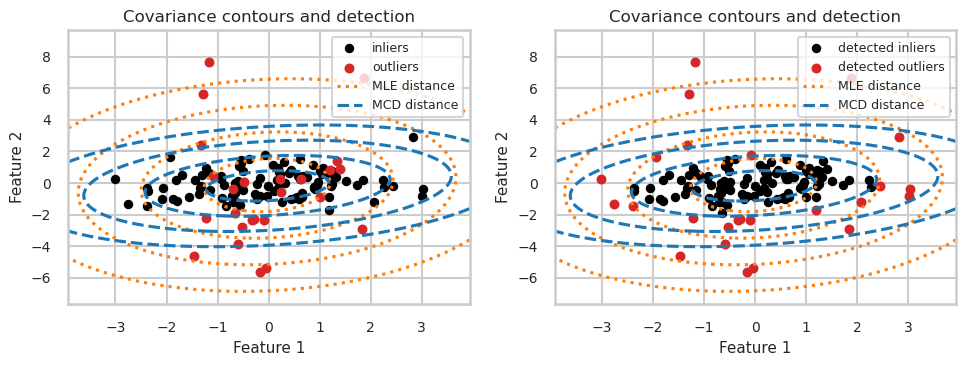

In [420]:
def _mahalanobis_surface(model, xlim, ylim, n_grid: int = 200):
    xx, yy = np.meshgrid(
        np.linspace(*xlim, n_grid),
        np.linspace(*ylim, n_grid),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = np.sqrt(model.mahalanobis(grid)).reshape(xx.shape)
    return xx, yy, zz

# Plot limits
pad = 0.15 * (X.max(axis=0) - X.min(axis=0))
xlim = (X[:, 0].min() - pad[0], X[:, 0].max() + pad[0])
ylim = (X[:, 1].min() - pad[1], X[:, 1].max() + pad[1])

xx, yy, zz_mle = _mahalanobis_surface(mle, xlim, ylim)
_, _, zz_mcd = _mahalanobis_surface(mcd, xlim, ylim)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# ------------------------------------------------------------
# 1) Scatter + covariance contours
# ------------------------------------------------------------
ax = axes[0]
ax.scatter(
        X[~y_true, 0], X[~y_true, 1],
        s=28, color="black", label="inliers"
    )
ax.scatter(
        X[y_true, 0], X[y_true, 1],
        s=32, color="tab:red", label="outliers"
    )

ax.contour(xx, yy, zz_mle, levels=[1, 2, 3, 4], colors="tab:orange", linestyles=":")
ax.contour(xx, yy, zz_mcd, levels=[1, 2, 3, 4], colors="tab:blue", linestyles="--")

# Legend entries for contours
ax.plot([], [], ":", color="tab:orange", label="MLE distance")
ax.plot([], [], "--", color="tab:blue", label="MCD distance")

ax.set_title("Covariance contours and detection", fontsize=12)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.tick_params(axis="both", labelsize=10)
ax.legend(fontsize=9, loc="upper right")


ax = axes[1]
ax.scatter(
        X[~detected, 0], X[~detected, 1],
        s=28, color="black", label="detected inliers"
    )
ax.scatter(
        X[detected, 0], X[detected, 1],
        s=32, color="tab:red", label="detected outliers"
    )

ax.contour(xx, yy, zz_mle, levels=[1, 2, 3, 4], colors="tab:orange", linestyles=":")
ax.contour(xx, yy, zz_mcd, levels=[1, 2, 3, 4], colors="tab:blue", linestyles="--")

# Legend entries for contours
ax.plot([], [], ":", color="tab:orange", label="MLE distance")
ax.plot([], [], "--", color="tab:blue", label="MCD distance")

ax.set_title("Covariance contours and detection", fontsize=12)
ax.set_xlabel("Feature 1", fontsize=11)
ax.set_ylabel("Feature 2", fontsize=11)
ax.tick_params(axis="both", labelsize=10)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

### Anomaly Detection Metrics

The cell then evaluates the detector with:

- **confusion matrix**
- **accuracy**
- **recall / sensitivity**
- **F1-score**

Unlike univariate rules, covariance-based methods use the **joint structure** of multiple variables. This is important in anomaly detection because a sample can look normal in each individual feature while still being atypical in the multivariate feature space.

Confusion matrix:
[[89 11]
 [11 14]]
TN=89, FP=11, FN=11, TP=14

Metrics:
    accuracy: 0.8240
 sensitivity: 0.5600
 specificity: 0.8900
    f1_score: 0.5600


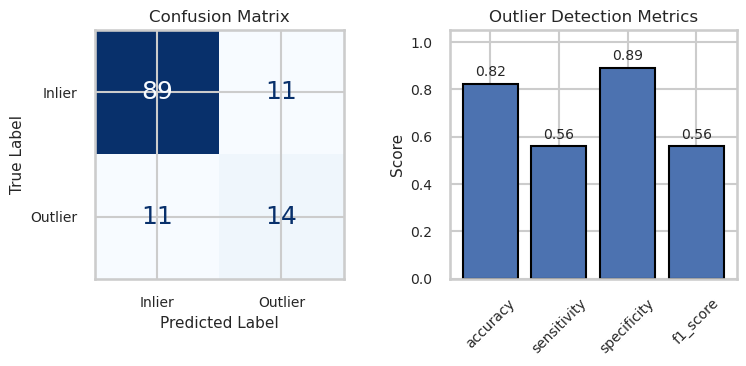

In [421]:
def evaluate_outlier_detection(y_true: np.ndarray, y_pred: np.ndarray):
    """
    Compute evaluation metrics for binary outlier detection.
    Positive class = outlier (True).
    """
    y_true = np.asarray(y_true, dtype=bool)
    y_pred = np.asarray(y_pred, dtype=bool)

    cm = confusion_matrix(y_true, y_pred, labels=[False, True])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": recall_score(~y_true, ~y_pred, zero_division=0),  # same as recall
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
    }

    return metrics, cm, (tn, fp, fn, tp)

# ------------------------------------------------------------
# Evaluate EllipticEnvelope detection
# ------------------------------------------------------------
metrics, cm, (tn, fp, fn, tp) = evaluate_outlier_detection(y_true, detected)

print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")

print("Metrics:")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")

# ------------------------------------------------------------
# Visualization: confusion matrix + metric bar chart
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Inlier", "Outlier"],
)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=12)
axes[0].tick_params(axis="both", labelsize=10)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

# Metrics
metric_names = ["accuracy", "sensitivity", "specificity", "f1_score"]
metric_values = [metrics[m] for m in metric_names]

bars = axes[1].bar(metric_names, metric_values, edgecolor="black")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Outlier Detection Metrics", fontsize=12)
axes[1].tick_params(axis="x", rotation=45, labelsize=10)
axes[1].tick_params(axis="y", labelsize=10)

for bar, value in zip(bars, metric_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 5. One-Class Support Vector Machines (Multivariate Anomaly Detection)

One-Class SVM is a widely used method for **unsupervised or weakly supervised anomaly detection**. In this setting, the ROC curve is particularly useful because it evaluates the detector across all possible decision thresholds, rather than at a single operating point. This helps quantify how well the anomaly score separates normal observations from rare abnormal events.

### Interpretation notes

- `y_true` is assumed to follow the convention:
  - `1` = outlier
  - `0` = inlier
- The ROC curve plots:
  - **False Positive Rate (FPR)** on the x-axis
  - **True Positive Rate (TPR)** on the y-axis
- The **AUC** summarizes the overall ranking performance of the anomaly score:
  - `AUC = 0.5` corresponds to random performance
  - `AUC = 1.0` corresponds to perfect separation

### Important technical note

As written, `OneClassSVM(gamma="auto", nu=contamination)` uses the default **RBF kernel**, not a linear kernel.  

Dataset shape: 1,831 samples x 21 features
Contamination (outlier fraction): 9.61%
Metrics RBF OC-SVM:
    accuracy: 0.8837
 sensitivity: 0.3977
 specificity: 0.9353
    f1_score: 0.3966


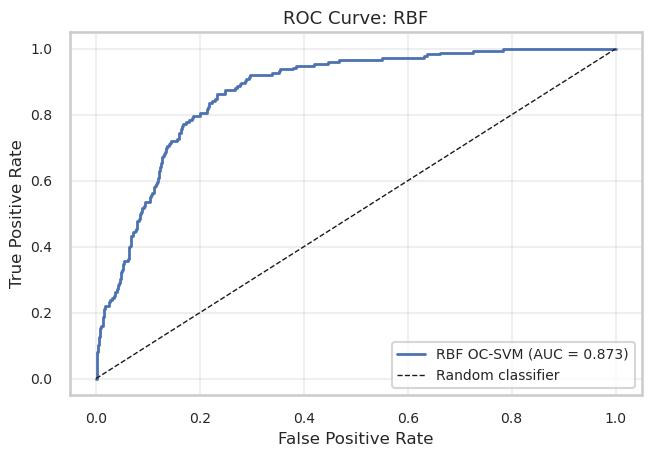

In [422]:
# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
X_ocsvm = np.load("datasets/6_cardio/X.npy")
X_ocsvm = StandardScaler().fit_transform(X_ocsvm)
y_true = np.load("datasets/6_cardio/y.npy").ravel()

contamination = np.mean(y_true == 1)
print(f"Dataset shape: {X_ocsvm.shape[0]:,} samples x {X_ocsvm.shape[1]:,} features")
print(f"Contamination (outlier fraction): {contamination:.2%}") 

# Ground-truth convention:
#   1 = outlier, 0 = inlier
# Change to outlier_label = -1 if your dataset uses {-1, 1}.
outlier_label = 1
y_bin = y_true == outlier_label
# ------------------------------------------------------------
# Fit One-Class SVM models
# ------------------------------------------------------------
ocsvm_rbf = OneClassSVM(gamma="auto", nu = contamination).fit(X_ocsvm)
# ------------------------------------------------------------
# Continuous anomaly scores
# Larger score = more anomalous
# decision_function is positive for inliers and negative for outliers,
# so we negate it for ROC analysis.
# ------------------------------------------------------------
scores_rbf = -ocsvm_rbf.decision_function(X_ocsvm).ravel()
# Optional binary predictions
y_pred_rbf = ocsvm_rbf.predict(X_ocsvm) == -1
# ------------------------------------------------------------
metrics, cm, (tn, fp, fn, tp) = evaluate_outlier_detection(y_bin, y_pred_rbf)
metrics = {
        "accuracy": accuracy_score(y_bin, y_pred_rbf),
        "sensitivity": recall_score(y_bin, y_pred_rbf, zero_division=0),
        "specificity": recall_score(~y_bin, ~y_pred_rbf, zero_division=0),  # same as recall
        "f1_score": f1_score(y_bin, y_pred_rbf, zero_division=0),
    }
# Metrics
metric_names = ["accuracy", "sensitivity", "specificity", "f1_score"]
metric_values = [metrics[m] for m in metric_names]
print("Metrics RBF OC-SVM:")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")
# ------------------------------------------------------------
# ROC curves and AUC
# ------------------------------------------------------------
fpr_rbf, tpr_rbf, _ = roc_curve(y_bin, scores_rbf)
auc_rbf = auc(fpr_rbf, tpr_rbf)
# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(fpr_rbf, tpr_rbf, lw=2, label=f"RBF OC-SVM (AUC = {auc_rbf:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve: RBF", fontsize=13)
plt.legend(fontsize=10, loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.tick_params(axis="both", labelsize=10)
plt.show()

## 6. Other Multivariable Anomaly Detection Methods

This cell loads the **6_cardio** dataset and applies one of two anomaly-detection methods selected by the user:

- **Isolation Forest**
- **Local Outlier Factor (LOF)**

Dataset shape: 1,831 samples x 21 features
Contamination (outlier fraction): 9.61%

Metrics: Isolation Forest
    accuracy: 0.9082
 sensitivity: 0.5227
 specificity: 0.9492
    f1_score: 0.5227


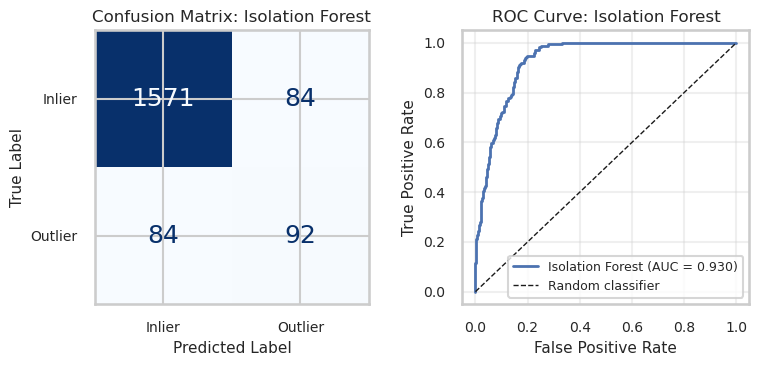

In [423]:
# ------------------------------------------------------------
# Choose method: "iforest" or "lof"
# ------------------------------------------------------------
METHOD = "iforest"   # change to "lof" for Local Outlier Factor

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
X = np.load("datasets/6_cardio/X.npy")
y_true = np.load("datasets/6_cardio/y.npy").ravel()

outlier_label = 1
y_bin = y_true == outlier_label
contamination = y_bin.mean()

print(f"Dataset shape: {X.shape[0]:,} samples x {X.shape[1]:,} features")
print(f"Contamination (outlier fraction): {contamination:.2%}")

# Scaling is especially useful for distance-based LOF
X_scaled = StandardScaler().fit_transform(X)

# ------------------------------------------------------------
# Fit model + anomaly scores
# Larger score = more anomalous
# ------------------------------------------------------------
if METHOD == "iforest":
    model = IsolationForest(contamination=contamination, random_state=42)
    y_pred = model.fit_predict(X_scaled) == -1
    scores = -model.decision_function(X_scaled).ravel()
    model_name = "Isolation Forest"

elif METHOD == "lof":
    model = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
    y_pred = model.fit_predict(X_scaled) == -1
    scores = -model.negative_outlier_factor_
    model_name = "Local Outlier Factor"

else:
    raise ValueError("METHOD must be 'iforest' or 'lof'.")

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------
cm = confusion_matrix(y_bin, y_pred, labels=[False, True])
tn, fp, fn, tp = cm.ravel()

metrics = {
    "accuracy": accuracy_score(y_bin, y_pred),
    "sensitivity": recall_score(y_bin, y_pred, zero_division=0),
    "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    "f1_score": f1_score(y_bin, y_pred, zero_division=0),
}

print(f"\nMetrics: {model_name}")
for name, value in metrics.items():
    print(f"{name:>12}: {value:.4f}")

# ------------------------------------------------------------
# ROC curve
# ------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_bin, scores)
roc_auc = auc(fpr, tpr)

# ------------------------------------------------------------
# Plots: confusion matrix + ROC
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Inlier", "Outlier"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix: {model_name}", fontsize=12)
axes[0].tick_params(axis="both", labelsize=10)
axes[0].set_xlabel("Predicted Label", fontsize=11)
axes[0].set_ylabel("True Label", fontsize=11)

axes[1].plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
axes[1].set_xlabel("False Positive Rate", fontsize=11)
axes[1].set_ylabel("True Positive Rate", fontsize=11)
axes[1].set_title(f"ROC Curve: {model_name}", fontsize=12)
axes[1].legend(fontsize=9, loc="lower right")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

## 7. Learning the Normal Behaviour Using a Regression Model

This cell builds a **residual-based anomaly-detection baseline**.

The workflow is:

1. apply the **MAD rule** to the log-transformed target KPI in order to identify a subset of samples considered *normal*,
2. keep only those non-anomalous samples for model fitting,
3. define the input matrix `X_train` using the explanatory features only,
4. define the response variable `y_train` as the `log10`-transformed throughput,
5. tune an **XGBoost regressor** with `RandomizedSearchCV`.

The purpose of this step is to learn the expected KPI behaviour under normal operating conditions.  
Later, anomalous behaviour can be investigated through the mismatch between the **observed KPI** and the **predicted KPI**. This approach is different from direct outlier detection methods such as One-Class SVM, Isolation Forest, or LOF.  
Here, anomalies are interpreted as **large prediction errors** with respect to a model of normal network behaviour.


In [424]:
mask = detect_outliers_mad(kpi_aux_log)
mask = ~mask  # Invert mask to keep non-outliers

X_train = data.loc[mask, data.columns != target_kpi].values
y_train = np.log10(data.loc[mask, target_kpi].values)

# Define parameter distributions for random search
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.5, 1, 5],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1]
}

# Create base XGBoost regressor
xgb_model = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)

# Perform random search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Fit the model
random_search.fit(X_train, y_train)

# Display best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
# Train final model with best parameters
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


### Evaluating predictive fit and visualizing candidate anomalies

This cell evaluates the fitted XGBoost model and visualizes its predictions.

- **MSE**, **RMSE**, **MAE**, and **R²** are computed on the training subset.
- The first scatter plot compares **actual** versus **predicted** `log10` throughput for the normal samples used during training.
- The second scatter plot overlays:
  - the training subset labeled as **Normal**
  - the previously filtered samples labeled as **Anomaly**

The red dashed line represents the ideal case in which prediction and observation coincide exactly.

### How to interpret the plots

- Points close to the diagonal indicate that the model explains the KPI well.
- Large deviations from the diagonal correspond to observations whose throughput is not consistent with the learned normal-behaviour model.
- In a residual-based anomaly detector, these deviations can be converted into an **anomaly score** and thresholded to produce final anomaly labels.


Training Metrics:
MSE: 0.0000
RMSE: 0.0009
MAE: 0.0007
R²: 1.0000


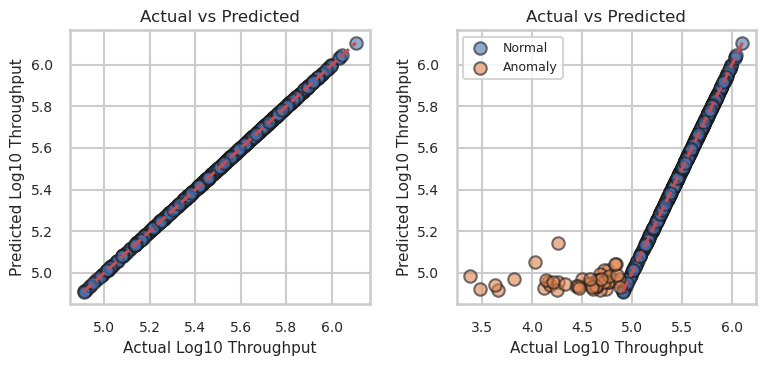

In [425]:

# Evaluate on training data
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"\nTraining Metrics:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

X_test = data.loc[~mask, data.columns != target_kpi].values
y_test = np.log10(data.loc[~mask, target_kpi].values)
y_test_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

axes[0].scatter(y_train, y_pred, alpha=0.6, edgecolor='k')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel("Actual Log10 Throughput", fontsize=11)
axes[0].set_ylabel("Predicted Log10 Throughput", fontsize=11)
axes[0].set_title("Actual vs Predicted", fontsize=12) 
axes[0].tick_params(axis="both", labelsize=10)

axes[1].scatter(y_train, y_pred, alpha=0.6, edgecolor='k', label="Normal")
axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolor='k', label="Anomaly")
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[1].set_xlabel("Actual Log10 Throughput", fontsize=11)
axes[1].set_ylabel("Predicted Log10 Throughput", fontsize=11)
axes[1].set_title("Actual vs Predicted", fontsize=12)
axes[1].tick_params(axis="both", labelsize=10) 
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()